# Assignment 3: Used Car Price Prediction, CarDekho Dataset

**Anshuman Atrey** · Roll No. 150096724029 · B.Tech CSE 2024-28, Semester V · Machine Learning Fundamentals (Google Classroom, ML(Elon Musk))

| | |
|---|------------------|
| **dataset** | [Vehicle dataset from CarDekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho) on kaggle, file `CAR DETAILS FROM CAR DEKHO.csv`: 4,340 listings, 8 columns |
| **my subset** | fuel type from my roll number: 150096724029 mod 3 = **0, so Petrol** cars (2,123 listings, more than the 150 minimum) |
| **target** | `selling_price` in rupees |
| **model** | Linear Regression on car age, km driven, transmission, owner (+ seller type, brand and model in the improved versions) |
| **result** | **test R-squared 0.840** (train 0.868, 5-fold cross-validation 0.848 ± 0.016), pass condition 0.75 |

## the whole thing in plain words

for anyone who has never touched machine learning:

1. **The task:** predict what a used car sells for on CarDekho, from its age, kilometres driven, gearbox, owner history and more, using Linear Regression.
2. **My slice of the data:** my roll number decides the fuel type (roll number mod 3 = 0, so Petrol). That gave 2,123 Petrol car listings.
3. **Cleaning:** 406 listings were exact copies, so they went, leaving 1,717 cars. Car age came from the year (the newest listing is from 2020), and the brand and model came from the car's name.
4. **Prices are lopsided:** 80% of the cars sell for under ₹5 lakh, but a few go up to ₹89 lakh. The logarithm of the price fixes that lopsided shape.
5. **Cars lose value in percentages:** on a log scale, price falls in a straight line with age, about 8.6% every year. Old cars also have more kilometres, so age and km tell partly the same story.
6. **The first model was weak:** using only the handout's features (age, km, gearbox, owner), it explained 42% of the price differences on cars it hadn't seen.
7. **What helped:** the log of price (to 62%), removing the most extreme cars (65%), adding the seller type (66%) and the brand (70%).
8. **The big jump:** the car model. A Maruti Alto and a Maruti Ciaz of the same age cost completely different amounts, and adding the model took it to 84%.
9. **The final score:** test R² 0.840 on cars it never saw (the pass mark was 0.75). Training R² is 0.868 and 5 different splits average 0.848, so it isn't memorising.
10. **What lowers resale value most:** each extra year of age -8.6%, a manual gearbox -14% against an automatic, selling as an individual -11% against a dealer, and every 10,000 km -2%.
11. **Limitations:** the typical error is about ₹55,000, and car models seen fewer than 10 times are lumped into "other", so rare cars are guessed less well.
12. **What gets handed in:** the notebook, a 1-page summary PDF, and this report (PDF and Word) with every step's explanation, code and output screenshot.

## 1. setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split

SEED = 42                                  # same split every run
ROLL_NUMBER = 150096724029
FIG = Path("figures")
FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.3.2 | numpy 2.2.6


## 2. loading the data and personalising the subset

the handout picks the fuel type from the roll number: roll number mod 3, where 0 = Petrol, 1 = Diesel, 2 = CNG / LPG / Electric. if the subset has fewer than 150 cars, Petrol cars get added until it reaches 150.

In [2]:
cars = pd.read_csv("data/CAR DETAILS FROM CAR DEKHO.csv")
print(f"full dataset: {cars.shape[0]} rows x {cars.shape[1]} columns")
print("fuel types:", cars["fuel"].value_counts().to_dict())

fuel_by_roll = {0: ["Petrol"], 1: ["Diesel"], 2: ["CNG", "LPG", "Electric"]}[ROLL_NUMBER % 3]
data = cars[cars["fuel"].isin(fuel_by_roll)].copy()
print(f"\n{ROLL_NUMBER} mod 3 = {ROLL_NUMBER % 3} -> {fuel_by_roll}: {len(data)} cars "
      f"({'enough' if len(data) >= 150 else 'fewer than 150'})")
data.head()

full dataset: 4340 rows x 8 columns
fuel types: {'Diesel': 2153, 'Petrol': 2123, 'CNG': 40, 'LPG': 23, 'Electric': 1}

150096724029 mod 3 = 0 -> ['Petrol']: 2123 cars (enough)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
5,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,2016,550000,25000,Petrol,Individual,Manual,First Owner


## 3. EDA: types, missing values, duplicate listings, outliers

In [3]:
print("types:", {c: str(t) for c, t in data.dtypes.items()})
print("missing values:", int(data.isna().sum().sum()))
print("duplicate listings:", int(data.duplicated().sum()))

def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return int(((s < q1 - 1.5 * (q3 - q1)) | (s > q3 + 1.5 * (q3 - q1))).sum())

print(f"outliers by the 1.5 x IQR rule: selling_price {iqr_outliers(data['selling_price'])}, "
      f"km_driven {iqr_outliers(data['km_driven'])}")
for col in ("seller_type", "transmission", "owner"):
    print(f"{col}: {data[col].value_counts().to_dict()}")
data[["year", "selling_price", "km_driven"]].describe().round(0)

types: {'name': 'object', 'year': 'int64', 'selling_price': 'int64', 'km_driven': 'int64', 'fuel': 'object', 'seller_type': 'object', 'transmission': 'object', 'owner': 'object'}
missing values: 0
duplicate listings: 406
outliers by the 1.5 x IQR rule: selling_price 62, km_driven 28
seller_type: {'Individual': 1615, 'Dealer': 454, 'Trustmark Dealer': 54}
transmission: {'Manual': 1930, 'Automatic': 193}
owner: {'First Owner': 1397, 'Second Owner': 529, 'Third Owner': 144, 'Fourth & Above Owner': 43, 'Test Drive Car': 10}


,year,selling_price,km_driven
count,2123.0,2123.0,2123.0
mean,2013.0,344840.0,52340.0
std,5.0,363673.0,38109.0
min,1992.0,20000.0,101.0
25%,2009.0,150000.0,25000.0
50%,2014.0,269000.0,50000.0
75%,2017.0,450000.0,70000.0
max,2020.0,8900000.0,806599.0


2,123 listings, 8 columns and no missing values. but **406 listings are exact duplicates** (19%), the same car posted more than once. prices go from 20,000 rupees to 89 lakh with a median of 2.69 lakh, so the IQR rule flags 62 price outliers, and km driven has 28, including one car claiming 806,599 km. the categories are lopsided: 1,930 manual against 193 automatic, and most sellers are individuals (1,615).

## 4. cleaning

- **duplicates:** the same listing appears more than once, so exact copies are dropped
- **`car_age`:** the newest car in the data is from 2020, so the listings are from about 2020. car age = 2020 - year
- **brand and model:** pulled out of `name` ("Maruti Swift Dzire VDI" -> brand Maruti, model "Maruti Swift"). not in the first model, used later when the model needs more information
- **encoding:** fuel, seller type, transmission and owner are text, so they get one-hot encoded (one 0/1 column per value) when the model is built. fuel only has one value left (Petrol), so it carries no information and drops out

In [4]:
data = data.drop_duplicates().copy()
REFERENCE_YEAR = data["year"].max()                        # 2020, when the listings were collected
data["car_age"] = REFERENCE_YEAR - data["year"]
data["brand"] = data["name"].str.split().str[0]
data["model"] = data["name"].str.split().str[:2].str.join(" ")
print(f"after dropping duplicates: {len(data)} cars | car_age range {data['car_age'].min()} to "
      f"{data['car_age'].max()} years | {data['brand'].nunique()} brands, {data['model'].nunique()} models")
print("fuel values left:", data["fuel"].unique().tolist(), "-> one value, so fuel drops out of the model")
data[["name", "brand", "model", "car_age", "km_driven", "selling_price"]].head()

after dropping duplicates: 1717 cars | car_age range 0 to 28 years | 25 brands, 118 models
fuel values left: ['Petrol'] -> one value, so fuel drops out of the model


,name,brand,model,car_age,km_driven,selling_price
0,Maruti 800 AC,Maruti,Maruti 800,13,70000,60000
1,Maruti Wagon R LXI Minor,Maruti,Maruti Wagon,13,50000,135000
3,Datsun RediGO T Option,Datsun,Datsun RediGO,3,46000,250000
5,Maruti Alto LX BSIII,Maruti,Maruti Alto,13,125000,140000
6,Hyundai Xcent 1.2 Kappa S,Hyundai,Hyundai Xcent,4,25000,550000


## 5. visualisations

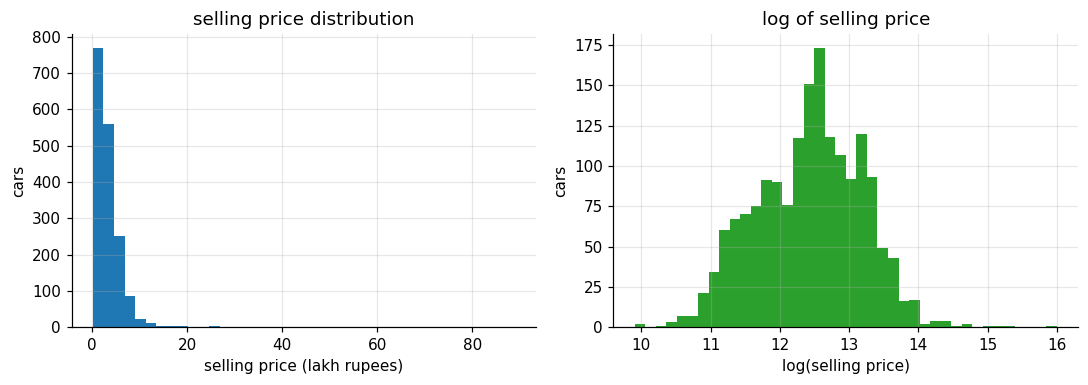

In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.6))
left.hist(data["selling_price"] / 1e5, bins=40, color="tab:blue")
left.set(title="selling price distribution", xlabel="selling price (lakh rupees)", ylabel="cars")
right.hist(np.log(data["selling_price"]), bins=40, color="tab:green")
right.set(title="log of selling price", xlabel="log(selling price)", ylabel="cars")
plt.tight_layout()
plt.savefig(FIG / "01_price_distribution.png", bbox_inches="tight")
plt.show()

price is lopsided: 80% of my cars sell for under 5 lakh, but the tail reaches 89 lakh. the log of price looks much more like a bell curve, which is what a straight-line model wants (step v2).

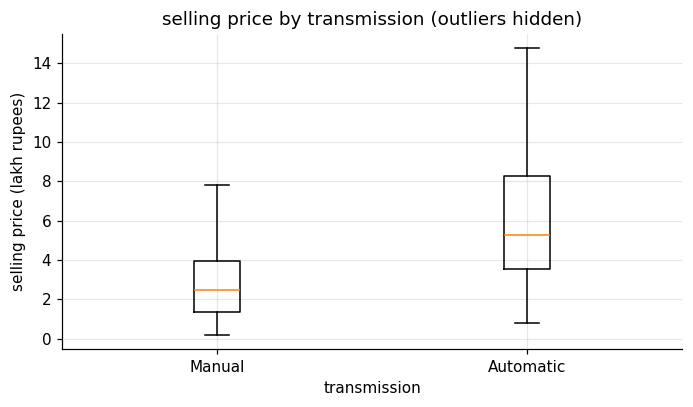

In [6]:
kinds = ["Manual", "Automatic"]
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.boxplot([data.loc[data["transmission"] == k, "selling_price"] / 1e5 for k in kinds], showfliers=False)
ax.set_xticks([1, 2], kinds)
ax.set(title="selling price by transmission (outliers hidden)", xlabel="transmission",
       ylabel="selling price (lakh rupees)")
plt.tight_layout()
plt.savefig(FIG / "02_price_by_transmission.png", bbox_inches="tight")
plt.show()

automatics sell for about double: a median of 5.25 lakh against 2.5 lakh for manuals, and their prices spread much wider. only about 1 car in 10 here is an automatic (193 of 2,123).

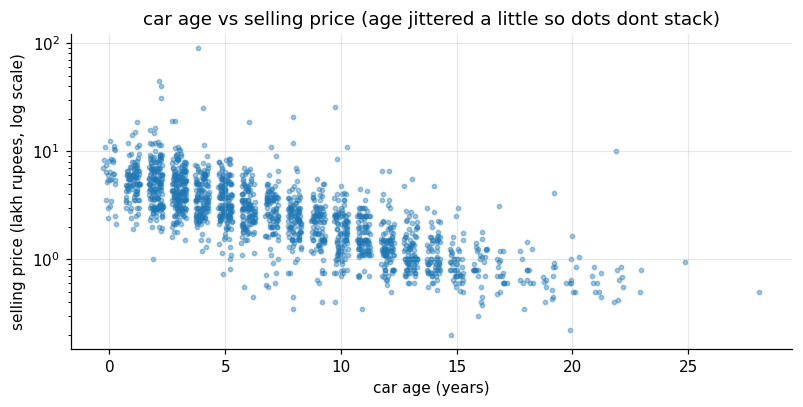

In [7]:
fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.scatter(data["car_age"] + np.random.default_rng(SEED).uniform(-0.3, 0.3, len(data)),
           data["selling_price"] / 1e5, s=8, alpha=0.4)
ax.set(yscale="log", title="car age vs selling price (age jittered a little so dots dont stack)",
       xlabel="car age (years)", ylabel="selling price (lakh rupees, log scale)")
plt.tight_layout()
plt.savefig(FIG / "03_age_vs_price.png", bbox_inches="tight")
plt.show()

on a log scale, price falls in an almost straight line as cars age. a straight line on a log scale means the car loses the same *percentage* of its value every year, which is why the model works on log(price). a 2-year-old car usually sells for 3 to 10 lakh, a 15-year-old one for around 1 lakh.

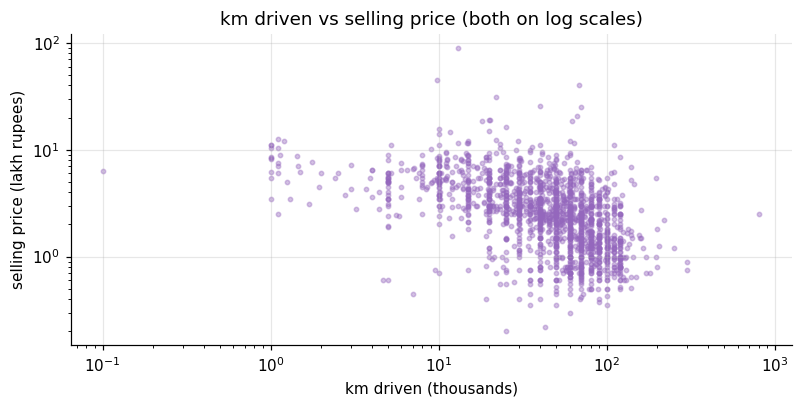

In [8]:
fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.scatter(data["km_driven"] / 1000, data["selling_price"] / 1e5, s=8, alpha=0.4, color="tab:purple")
ax.set(xscale="log", yscale="log", title="km driven vs selling price (both on log scales)",
       xlabel="km driven (thousands)", ylabel="selling price (lakh rupees)")
plt.tight_layout()
plt.savefig(FIG / "04_km_vs_price.png", bbox_inches="tight")
plt.show()

more kilometres means a lower price, but the cloud is much messier than for age. km and age go together (correlation 0.52), so part of what looks like a km effect is really an age effect. the odd ones stand out too: one car with just 101 km and one with 806,599 km.

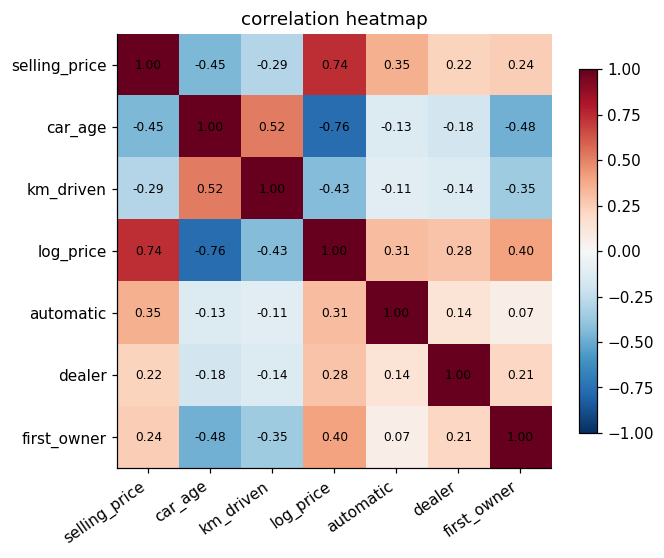

In [9]:
numeric = data[["selling_price", "car_age", "km_driven"]].assign(
    log_price=np.log(data["selling_price"]),
    automatic=(data["transmission"] == "Automatic").astype(float),
    dealer=(data["seller_type"] != "Individual").astype(float),
    first_owner=(data["owner"] == "First Owner").astype(float))
corr = numeric.corr()
fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=35, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("correlation heatmap")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(FIG / "05_correlation_heatmap.png", bbox_inches="tight")
plt.show()

log_price moves strongly with car age (-0.76), much more than the raw price does (-0.45), another sign that log is the right scale. being the first owner (+0.40), automatic (+0.31) and sold by a dealer (+0.28) all push the price up, and km driven pulls it down (-0.43).

## 6. first model

the handout model: Linear Regression predicting selling price from car age, km driven, fuel, transmission and owner. fuel is a single value in my Petrol subset, so it drops out. 80/20 train/test split, scored with R-squared on both sets, RMSE, and also 5-fold cross-validation (5 different splits), because one split can be lucky.

In [10]:
CATEGORIES = ["transmission", "owner", "seller_type", "brand", "model"]


def build_features(frame, columns, min_count=10):
    """chosen columns, text ones one-hot encoded. brands / models seen fewer than min_count times -> 'other'."""
    frame = frame[columns].copy()
    for col in ("brand", "model"):
        if col in frame:
            counts = frame[col].value_counts()
            frame[col] = frame[col].where(frame[col].map(counts) >= min_count, "other")
    text = [c for c in columns if c in CATEGORIES]
    return pd.get_dummies(frame, columns=text, drop_first=True, dtype=float)


def evaluate(frame, columns, log_price=False):
    """80/20 split + 5-fold cross-validation -> scores, fitted model, features, test predictions in rupees."""
    X = build_features(frame, columns)
    y = np.log(frame["selling_price"]) if log_price else frame["selling_price"]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)
    model = LinearRegression().fit(X_tr, y_tr)
    cv = cross_val_score(LinearRegression(), X, y, cv=KFold(5, shuffle=True, random_state=SEED),
                         scoring="r2")
    to_rupees = np.exp if log_price else (lambda v: v)
    actual, pred = to_rupees(y_te), to_rupees(model.predict(X_te))
    scores = {"train R2": r2_score(y_tr, model.predict(X_tr)), "test R2": r2_score(y_te, model.predict(X_te)),
              "5-fold CV R2": cv.mean(), "CV spread": cv.std(),
              "test RMSE (lakh)": np.sqrt(mean_squared_error(actual, pred)) / 1e5,
              "test MAE (lakh)": mean_absolute_error(actual, pred) / 1e5}
    return scores, model, X, (actual, pred)


HANDOUT = ["car_age", "km_driven", "transmission", "owner"]       # fuel dropped, it is constant
v1, *_ = evaluate(data, HANDOUT)
print(" | ".join(f"{k} {v:.3f}" for k, v in v1.items()))

train R2 0.287 | test R2 0.418 | 5-fold CV R2 0.350 | CV spread 0.101 | test RMSE (lakh) 2.051 | test MAE (lakh) 1.364


with only the handout's features and the raw price, the model is weak: test R² 0.418, train only 0.287, and 0.350 across 5 splits. a straight line in rupees cant follow a car that loses a percentage of its value every year.

## 7. iterating until it passes

the handout says: handle the skew in price with a log-transform, remove extreme outliers, add or remove features. each step changes one thing:

- **log of price:** a car losing value loses a percentage each year, not a fixed amount, so log(price) turns that into a straight line
- **extreme outliers:** the cheapest 1% and priciest 1% of cars, and the 1% with the most kilometres (one claims 806,599 km), are dropped
- **seller type:** dealers price differently from individuals
- **brand and model:** a 2015 Maruti Alto and a 2015 Honda City are completely different prices. the brand and model come from the name, and ones seen fewer than 10 times are grouped as "other"

In [11]:
low, high = data["selling_price"].quantile([0.01, 0.99])
trimmed = data[data["selling_price"].between(low, high) & (data["km_driven"] <= data["km_driven"].quantile(0.99))]
steps = [("v1 handout features, price as is", data, HANDOUT, False),
         ("v2 + log of price", data, HANDOUT, True),
         ("v3 + extreme outliers removed", trimmed, HANDOUT, True),
         ("v4 + seller type", trimmed, HANDOUT + ["seller_type"], True),
         ("v5 + brand", trimmed, HANDOUT + ["seller_type", "brand"], True),
         ("v6 + model (final)", trimmed, HANDOUT + ["seller_type", "brand", "model"], True)]
rows = []
for name, frame, columns, log_price in steps:
    scores, *_ = evaluate(frame, columns, log_price)
    rows.append({"step": name, "rows": len(frame), "features": len(build_features(frame, columns).columns),
                 **scores})
iterations = pd.DataFrame(rows).set_index("step")
iterations.round(3)

,rows,features,train R2,test R2,5-fold CV R2,CV spread,test RMSE (lakh),test MAE (lakh)
step,,,,,,,,
"v1 handout features, price as is",1717,7,0.287,0.418,0.350,0.101,2.051,1.364
v2 + log of price,1717,7,0.635,0.621,0.629,0.028,2.108,1.260
v3 + extreme outliers removed,1667,7,0.628,0.651,0.630,0.042,1.429,0.953
v4 + seller type,1667,9,0.643,0.664,0.643,0.033,1.410,0.926
v5 + brand,1667,22,0.737,0.703,0.722,0.026,1.345,0.895
v6 + model (final),1667,67,0.868,0.840,0.848,0.016,0.890,0.549


what each step did:

- **v2, log of price:** the biggest single jump, CV from 0.35 to 0.63. the line can now follow the percentage drop per year
- **v3, extreme outliers removed:** 50 cars go, the RMSE drops from 2.11 to 1.43 lakh, CV stays at 0.63
- **v4, seller type:** dealers against individuals, CV 0.64
- **v5, brand:** Maruti against Honda against BMW, CV 0.72
- **v6, model:** the big one. models of the same brand (Alto, Swift, Ciaz) are very different cars. CV 0.848, test R² 0.840, and the smallest spread (0.016)

v6 is the only version that passes the 0.75 bar, and it holds up across all 5 cross-validation splits.

## 8. checking the final model

final model: train R2 0.868 | test R2 0.840 | gap +0.028
5-fold cross-validation R2: 0.848 +- 0.016
test RMSE 0.89 lakh | test MAE 0.55 lakh | median test price 2.50 lakh


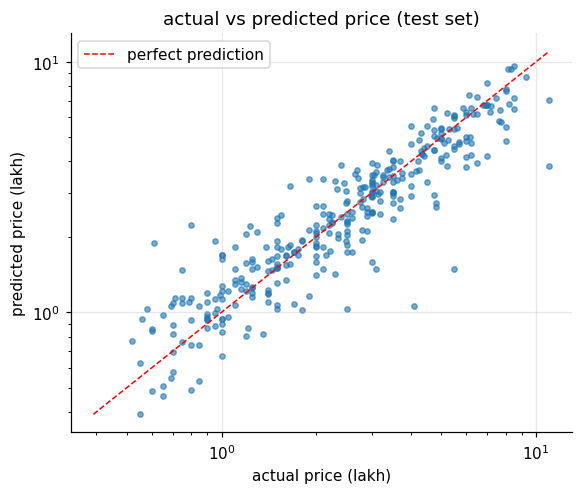

In [12]:
FINAL = HANDOUT + ["seller_type", "brand", "model"]
final, model, X_all, (actual, pred) = evaluate(trimmed, FINAL, True)
train_r2, test_r2 = final["train R2"], final["test R2"]
print(f"final model: train R2 {train_r2:.3f} | test R2 {test_r2:.3f} | gap {train_r2 - test_r2:+.3f}")
print(f"5-fold cross-validation R2: {final['5-fold CV R2']:.3f} +- {final['CV spread']:.3f}")
print(f"test RMSE {final['test RMSE (lakh)']:.2f} lakh | test MAE {final['test MAE (lakh)']:.2f} lakh "
      f"| median test price {np.median(actual) / 1e5:.2f} lakh")

fig, ax = plt.subplots(figsize=(5.4, 4.6))
ax.scatter(actual / 1e5, pred / 1e5, s=12, alpha=0.6)
lims = [min(actual.min(), pred.min()) / 1e5, max(actual.max(), pred.max()) / 1e5]
ax.plot(lims, lims, "r--", lw=1, label="perfect prediction")
ax.set(xscale="log", yscale="log", title="actual vs predicted price (test set)",
       xlabel="actual price (lakh)", ylabel="predicted price (lakh)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "06_actual_vs_predicted.png", bbox_inches="tight")
plt.show()

In [13]:
coef = pd.Series(model.coef_, index=X_all.columns)
effect = lambda c, times=1: f"{np.expm1(coef[c] * times):+.1%}"
print("what lowers resale value (holding everything else fixed):")
print(f"  each extra year of age:      {effect('car_age')}")
print(f"  every extra 10,000 km:       {effect('km_driven', 10_000)}")
for c in [c for c in coef.index if c.startswith("owner_")]:
    print(f"  {c.replace('owner_', ''):27s} {effect(c)}  (vs First Owner)")
print(f"  manual vs automatic:         {effect('transmission_Manual')}")
for c in [c for c in coef.index if c.startswith("seller_type_")]:
    print(f"  {c.replace('seller_type_', '') + ' seller':27s} {effect(c)}  (vs Dealer)")

what lowers resale value (holding everything else fixed):
  each extra year of age:      -8.6%
  every extra 10,000 km:       -2.1%
  Fourth & Above Owner        -5.0%  (vs First Owner)
  Second Owner                -1.2%  (vs First Owner)
  Test Drive Car              +11.4%  (vs First Owner)
  Third Owner                 -9.8%  (vs First Owner)
  manual vs automatic:         -14.2%
  Individual seller           -10.9%  (vs Dealer)
  Trustmark Dealer seller     +13.1%  (vs Dealer)


train R² 0.868 against test R² 0.840: a small gap (0.028), so its not memorising the training cars, and 5 different splits give 0.848 ± 0.016. the typical error (MAE) is 0.55 lakh on a median test price of 2.5 lakh. the plot follows the diagonal, with the most spread at the expensive end, where there are few cars to learn from.

**what lowers resale value**, holding everything else fixed:

- **age:** -8.6% for every extra year, the biggest steady effect
- **transmission:** a manual sells for 14.2% less than the same car as an automatic
- **seller:** -10.9% when an individual sells instead of a dealer (trustmark dealers get +13.1%, a certified-car premium)
- **km driven:** -2.1% for every extra 10,000 km
- **owners:** a third owner costs 9.8% against a first owner. the fourth-and-above group (39 cars) is too small to be reliable (-5.0%), and the 10 "test drive cars" are nearly new demo cars (+11.4%)

## 9. summary

**what reduced resale value the most.** in my Petrol subset, **age** is the steadiest value killer: every year costs about 8.6% of the price, holding everything else fixed, and on a log scale the price falls in an almost straight line with age. the **gearbox** comes next: a manual sells for about 14% less than the same car as an automatic. **who sells it** matters too: individual sellers get about 11% less than dealers. **kilometres** cost about 2% per 10,000 km, smaller than it looks in the plots, because high-km cars are mostly old cars too. a third owner takes about 10% off. and the biggest single factor is simply **which car it is**: brand and model took the test R² from 0.66 to 0.84.

**why the final model performs as it does.** cars lose value in percentages, so a straight line on raw rupees fits badly (test R² 0.42). on log(price) the age effect becomes a straight line, and the brand and model columns tell the model what kind of car it is, which the handout's 5 features alone cannot. with 1,667 cars and 67 features the model still generalises: train 0.868, test 0.840, cross-validation 0.848 ± 0.016.

**limits.** models seen fewer than 10 times are grouped as "other", so rare cars are guessed less well, and the typical error is about 55,000 rupees.

In [14]:
summary = pd.Series({
    "subset": f"Petrol cars (roll mod 3 = 0), {len(cars[cars['fuel'] == 'Petrol'])} listings",
    "rows used by the final model": f"{len(trimmed)}",
    "final model": "Linear Regression: log(price) from age, km, transmission, owner, seller, brand, model",
    "train R2 / test R2": f"{train_r2:.3f} / {test_r2:.3f}",
    "5-fold cross-validation R2": f"{final['5-fold CV R2']:.3f} +- {final['CV spread']:.3f}",
    "test RMSE / MAE": f"{final['test RMSE (lakh)']:.2f} / {final['test MAE (lakh)']:.2f} lakh",
    "pass condition (test R2 >= 0.75)": "passed" if test_r2 >= 0.75 else "not passed",
}, name="value")
summary.to_frame()

,value
subset,"Petrol cars (roll mod 3 = 0), 2123 listings"
rows used by the final model,1667
final model,"Linear Regression: log(price) from age, km, tr..."
train R2 / test R2,0.868 / 0.840
5-fold cross-validation R2,0.848 +- 0.016
test RMSE / MAE,0.89 / 0.55 lakh
pass condition (test R2 >= 0.75),passed
